In [1]:
# 
# 데이터셋에서 11개 패드에 각각 백본 + 공유엑스퍼트
# fastvit_t8 (모델 내에 어텐션 없음)
#
# =============================================================================
# 환경 설정 & 라이브러리 임포트
# =============================================================================
import os
import gc
import glob
import pickle
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from tqdm import tqdm
import timm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import h5py

# GPU 설정
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # 사용할 GPU 지정
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

def clear_gpu_memory():
    """GPU 메모리 정리"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

In [2]:
# =============================================================================
# 벨 매핑 규칙 정의 (Multi-Task Learning 용)
# =============================================================================
#
# 33개의 메인 클래스 정의
MAIN_CLASSES = sorted(['Bilirubin_1',
 'Nonhemo_250',
 'Nonhemo_10',
 'Glucose_2000',
 'Nonhemo_50',
 'Glucose_1000',
 'Ctrl',
 'Glucose_350',
 'pH_9',
 'Glucose_250',
 'Bilirubin_3',
 'Protein_10',
 'pH_6.5',
 'Glucose_100',
 'pH_8',
 'pH_6',
 'Glucose_500',
 'Nitrite_1',
 'Protein_1000',
 'Protein_30',
 'Hemo_250',
 'Protein_300',
 'pH_5',
 'Nitrite_0.5',
 'pH_7',
 'Glucose_1500',
 'Hemo_10',
 'Glucose_150',
 'Bilirubin_0.5',
 'Glucose_750',
 'Protein_100',
 'pH_7.5',
 'Hemo_50'])

#  6개 그룹별 클래스ㅅ
#    - 0번 인덱스는 항상 음성 클래스로 고정 (pH 제외)
AUX_CLASSES_GROUPS = {
    # 0번 패드: Hemo/NonHemo (총 7개 클래스)
    'aux_0': sorted(['Hemo_Negative', 'Hemo_10', 'Hemo_50', 'Hemo_250', 'Nonhemo_10', 'Nonhemo_50', 'Nonhemo_250']),
    
    # 1번 패드: Bilirubin (총 4개 클래스)
    'aux_1': sorted(['Bilirubin_Negative', 'Bilirubin_0.5', 'Bilirubin_1', 'Bilirubin_3']),
    
    # 4번 패드: Protein (총 6개 클래스)
    'aux_4': sorted(['Protein_Negative', 'Protein_10', 'Protein_30', 'Protein_100', 'Protein_300', 'Protein_1000']),
    
    # 5번 패드: Nitrite (총 3개 클래스)
    'aux_5': sorted(['Nitrite_Negative', 'Nitrite_0.5', 'Nitrite_1']),
    
    # 6번 패드: Glucose (총 10개 클래스)
    'aux_6': sorted(['Glucose_Negative', 'Glucose_100', 'Glucose_150', 'Glucose_250', 'Glucose_350', 'Glucose_500', 'Glucose_750', 'Glucose_1000', 'Glucose_1500', 'Glucose_2000']),
    
    # 7번 패드: pH (총 7개 클래스, 'Negative' 없음, 'IGNORE'(-1) 신호 사용)
    'aux_7': sorted(['pH_5', 'pH_6', 'pH_6.5', 'pH_7', 'pH_7.5', 'pH_8', 'pH_9'])
}

# "메인 라벨 -> 6개 보조 라벨" 번역 규칙 딕셔너리
# - 'IGNORE'는 Loss 계산에서 제외
MAIN_TO_AUX_MAP = {}

# 기본 '음성' 상태 정의
DEFAULT_NEGATIVE_LABELS = {
    'aux_0': 'Hemo_Negative',
    'aux_1': 'Bilirubin_Negative',
    'aux_4': 'Protein_Negative',
    'aux_5': 'Nitrite_Negative',
    'aux_6': 'Glucose_Negative',
    'aux_7': 'IGNORE'  # pH는 'Negative'가 없고 'IGNORE' 처리
}

# 33개 메인 클래스에 대해
for main_label_name in MAIN_CLASSES:
    # 모든 보조 라벨을 기본 '음성' 상태로 초기화
    aux_labels = DEFAULT_NEGATIVE_LABELS.copy()
    
    if main_label_name == 'Ctrl':
        # 'Ctrl'은 모든 보조 라벨이 '음성'이므로, 'aux_labels'를 그대로 사용
        pass
        
    # 2. '양성' 클래스인 경우, 해당하는 보조 라벨만 덮어쓰기
    elif main_label_name.startswith('Hemo_') or main_label_name.startswith('Nonhemo_'):
        aux_labels['aux_0'] = main_label_name
        
    elif main_label_name.startswith('Bilirubin_'):
        aux_labels['aux_1'] = main_label_name
        
    elif main_label_name.startswith('Protein_'):
        aux_labels['aux_4'] = main_label_name
        
    elif main_label_name.startswith('Nitrite_'):
        aux_labels['aux_5'] = main_label_name
        
    elif main_label_name.startswith('Glucose_'):
        aux_labels['aux_6'] = main_label_name
        
    elif main_label_name.startswith('pH_'):
        aux_labels['aux_7'] = main_label_name # 'IGNORE' 대신 실제 pH 값으로 덮어쓰기
    
    # 완성된 6개 보조 라벨 튜플을 맵에 저장
    MAIN_TO_AUX_MAP[main_label_name] = (
        aux_labels['aux_0'],
        aux_labels['aux_1'],
        aux_labels['aux_4'],
        aux_labels['aux_5'],
        aux_labels['aux_6'],
        aux_labels['aux_7']
    )

# 4. 보조 라벨 이름(str)을 인덱스(int)로 변환하는 헬퍼 딕셔너리 생성
#    - 'IGNORE'는 -1로 매핑
AUX_NAME_TO_INDEX_MAP = {
    group_name: {name: i for i, name in enumerate(names)}
    for group_name, names in AUX_CLASSES_GROUPS.items()
}
# 'IGNORE' 신호(-1) 추가
for group_name in AUX_NAME_TO_INDEX_MAP:
    AUX_NAME_TO_INDEX_MAP[group_name]['IGNORE'] = -1

print("✅ [신규 셀] 라벨 매핑 규칙(MAIN_TO_AUX_MAP)이 성공적으로 생성되었습니다.")
print(f"  - 예시 (Ctrl): {MAIN_TO_AUX_MAP['Ctrl']}")
print(f"  - 예시 (Protein_300): {MAIN_TO_AUX_MAP['Protein_300']}")
print(f"  - 예시 (pH_5): {MAIN_TO_AUX_MAP['pH_5']}")

✅ [신규 셀] 라벨 매핑 규칙(MAIN_TO_AUX_MAP)이 성공적으로 생성되었습니다.
  - 예시 (Ctrl): ('Hemo_Negative', 'Bilirubin_Negative', 'Protein_Negative', 'Nitrite_Negative', 'Glucose_Negative', 'IGNORE')
  - 예시 (Protein_300): ('Hemo_Negative', 'Bilirubin_Negative', 'Protein_300', 'Nitrite_Negative', 'Glucose_Negative', 'IGNORE')
  - 예시 (pH_5): ('Hemo_Negative', 'Bilirubin_Negative', 'Protein_Negative', 'Nitrite_Negative', 'Glucose_Negative', 'pH_5')


In [3]:
# =============================================================================
# HDF5UrinKitDataset
# =============================================================================

class HDF5UrinKitDataset(Dataset):
    """
    HDF5 파일에서 센서 세트 데이터를 로드 (Multi-Task Learning 지원)
    """
    def __init__(self, h5_path):
        self.h5_path = h5_path
        
        # 라벨 매핑 규칙이 정의되어 있는지 확인 (앞의 [신규 셀] 실행 필수)
        if 'MAIN_CLASSES' not in globals() or 'MAIN_TO_AUX_MAP' not in globals():
            raise RuntimeError("라벨 매핑 규칙(MAIN_CLASSES 등)이 정의되지 않았습니다. [신규 셀]을 먼저 실행하세요.")

        with h5py.File(h5_path, 'r') as f:
            self.length = len([k for k in f.keys() if k.startswith('sensor')])
            
        print(f"HDF5 데이터 준비 완료: {self.length}개 센서 세트 (MTL 모드)")
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        """
        필요할 때만 데이터 로드
        Returns:
            tuple: (
                sensor_set (torch.Tensor): (11, 3, 224, 224) 이미지 세트
                main_label (torch.Tensor): (1,) 메인 라벨 (예: 'Protein_300'의 인덱스)
                aux_labels (torch.Tensor): (6,) 보조 라벨 6개의 인덱스 텐서
            )
        """
        with h5py.File(self.h5_path, 'r') as f:
            sensor_set = torch.from_numpy(f[f'sensor_{idx}'][:])
            
            # 1. 메인 라벨(스칼라) 로드
            label_data = f[f'label_{idx}']
            if label_data.shape == ():  # 스칼라인 경우
                main_label_idx = torch.tensor(label_data[()])
            else:  # 배열인 경우
                main_label_idx = torch.from_numpy(label_data[:]).squeeze()
        
        # 2. [신규] 메인 라벨을 6개 보조 라벨로 "번역"
        try:
            # 메인 라벨 인덱스 -> 메인 라벨 이름 (예: 25 -> 'Protein_300')
            main_label_name = MAIN_CLASSES[main_label_idx.item()]
            
            # 메인 라벨 이름 -> 6개 보조 라벨 이름 (예: ('Hemo_Negative', ..., 'Protein_300', ..., 'IGNORE'))
            aux_label_names = MAIN_TO_AUX_MAP[main_label_name]
            
            # 6개 보조 라벨 이름 -> 6개 보조 라벨 인덱스 (예: (0, 0, 4, 0, 0, -1))
            aux_label_indices = [
                AUX_NAME_TO_INDEX_MAP['aux_0'][aux_label_names[0]], # Hemo
                AUX_NAME_TO_INDEX_MAP['aux_1'][aux_label_names[1]], # Bili
                AUX_NAME_TO_INDEX_MAP['aux_4'][aux_label_names[2]], # Protein
                AUX_NAME_TO_INDEX_MAP['aux_5'][aux_label_names[3]], # Nitrite
                AUX_NAME_TO_INDEX_MAP['aux_6'][aux_label_names[4]], # Glucose
                AUX_NAME_TO_INDEX_MAP['aux_7'][aux_label_names[5]]  # pH
            ]
            
            aux_labels_tensor = torch.tensor(aux_label_indices, dtype=torch.long)
            
        except IndexError:
            print(f"치명적 오류: HDF5의 메인 라벨 인덱스 {main_label_idx.item()}가 MAIN_CLASSES (총 {len(MAIN_CLASSES)}개) 범위를 벗어납니다.")
            raise
        except KeyError:
            print(f"치명적 오류: 메인 라벨 {main_label_name}을(를) MAIN_TO_AUX_MAP에서 찾을 수 없습니다.")
            raise

        return sensor_set, main_label_idx, aux_labels_tensor

# --- Pickle to HDF5 변환 함수 ---
def convert_pickle_to_hdf5(pickle_path, h5_path):
    """Pickle 파일을 HDF5로 변환"""
    print(f"변환 시작: {pickle_path} → {h5_path}")
    
    with open(pickle_path, 'rb') as f:
        data = pickle.load(f)
    
    with h5py.File(h5_path, 'w') as f:
        for i, (sensor_set, label) in enumerate(tqdm(data, desc="HDF5 변환")):
            f.create_dataset(f'sensor_{i}', data=sensor_set.numpy(), compression='gzip')
            # 라벨을 스칼라로 저장
            if hasattr(label, 'item'):
                f.create_dataset(f'label_{i}', data=label.item())
            else:
                f.create_dataset(f'label_{i}', data=label)
    
    print(f"변환 완료: {len(data)}개 샘플")

In [4]:
# =============================================================================
# [수정된 셀 3] NaturePaperStyleDataset
# - __getitem__이 3개 값(sensor_set, main_label, aux_labels)을
#   올바르게 처리하도록 수정
# =============================================================================

import random
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageEnhance, ImageFilter
from torchvision import transforms as T
import cv2
from typing import List, Tuple, Dict, Optional

# (NaturePaperAugmentation, ProfessionalDataAugmentation, AddressEnvironmentalAugmentation
#  클래스들은 기존과 동일 - 수정 없음)

class NaturePaperAugmentation:
    """Nature Communications 논문 스타일의 체계적 데이터 증강"""
    
    def __init__(self, augmentation_level: str = "all_surroundings"):
        self.augmentation_level = augmentation_level
        self.setup_augmentation_parameters()
    
    def setup_augmentation_parameters(self):
        """논문 기반 증강 파라미터 설정"""
        if self.augmentation_level == "single_light":
            self.brightness_range = (0.8, 1.2)
            self.contrast_range = (0.8, 1.2)
            self.color_temp_range = (0.9, 1.1)
            self.blur_sigma_range = (0.1, 0.5)
            self.crop_scale_range = (0.9, 1.0)
        elif self.augmentation_level == "multi_light":
            self.brightness_range = (0.6, 1.4)
            self.contrast_range = (0.7, 1.3)
            self.color_temp_range = (0.85, 1.15)
            self.blur_sigma_range = (0.1, 0.8)
            self.crop_scale_range = (0.85, 1.0)
        else:  # "all_surroundings"
            self.brightness_range = (0.4, 1.6)
            self.contrast_range = (0.5, 1.5)
            self.color_temp_range = (0.8, 1.2)
            self.blur_sigma_range = (0.1, 1.2)
            self.crop_scale_range = (0.8, 1.0)

class ProfessionalDataAugmentation:
    """논문 수준의 전문적 데이터 증강 시스템"""
    
    def __init__(self, config: NaturePaperAugmentation):
        self.config = config
        
    def apply_color_temperature_modulation(self, image: Image.Image, intensity: float = None) -> Image.Image:
        """색온도 변조 - 스마트폰별 색상 차이 대응"""
        if intensity is None:
            intensity = random.uniform(*self.config.color_temp_range)
        
        r, g, b = image.split()
        
        if intensity > 1.0:
            r_factor = intensity
            b_factor = 1.0 / intensity
            g_factor = 1.0
        else:
            r_factor = intensity
            b_factor = 1.0 / intensity  
            g_factor = 1.0
        
        r = ImageEnhance.Brightness(r).enhance(r_factor)
        b = ImageEnhance.Brightness(b).enhance(b_factor)
        g = ImageEnhance.Brightness(g).enhance(g_factor)
        
        return Image.merge('RGB', (r, g, b))
    
    def apply_contrast_modulation(self, image: Image.Image, intensity: float = None) -> Image.Image:
        """대비 변조 - 카메라 센서 품질 차이 대응"""
        if intensity is None:
            intensity = random.uniform(*self.config.contrast_range)
        
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(intensity)
    
    def apply_brightness_modulation(self, image: Image.Image, intensity: float = None) -> Image.Image:
        """밝기 변조 - 조명 환경 변화 대응"""
        if intensity is None:
            intensity = random.uniform(*self.config.brightness_range)
        
        enhancer = ImageEnhance.Brightness(image)
        return enhancer.enhance(intensity)
    
    def apply_gaussian_blur(self, image: Image.Image, sigma: float = None) -> Image.Image:
        """가우시안 블러 - 촬영 시 초점 문제 대응"""
        if sigma is None:
            sigma = random.uniform(*self.config.blur_sigma_range)
        
        return image.filter(ImageFilter.GaussianBlur(radius=sigma))
    
    def apply_horizontal_flip(self, image: Image.Image, probability: float = 0.5) -> Image.Image:
        """수평 뒤집기 - 촬영 각도 변화 대응"""
        if random.random() < probability:
            return image.transpose(Image.FLIP_LEFT_RIGHT)
        return image
    
    def apply_stochastic_crop_resize(self, image: Image.Image, scale_range: Tuple[float, float] = None) -> Image.Image:
        """확률적 크롭 및 리사이징 - 거리/위치 변화 대응"""
        if scale_range is None:
            scale_range = self.config.crop_scale_range
        
        scale = random.uniform(*scale_range)
        width, height = image.size
        
        new_width = int(width * scale)
        new_height = int(height * scale)
        
        left = random.randint(0, width - new_width)
        top = random.randint(0, height - new_height)
        
        cropped = image.crop((left, top, left + new_width, top + new_height))
        return cropped.resize((width, height), Image.LANCZOS)

class AdvancedEnvironmentalAugmentation:
    """고급 환경적 증강"""
    
    def apply_lighting_condition_simulation(self, image: Image.Image) -> Image.Image:
        """조명 조건 시뮬레이션"""
        lighting_scenarios = [
            ("dim_indoor", 0.3, 0.8),
            ("office_fluorescent", 0.9, 1.1),
            ("bright_outdoor", 1.3, 1.5),
            ("hospital_led", 1.1, 1.2),
            ("car_interior", 0.4, 0.7),
        ]
        
        scenario_name, min_bright, max_bright = random.choice(lighting_scenarios)
        brightness = random.uniform(min_bright, max_bright)
        
        return ImageEnhance.Brightness(image).enhance(brightness)
    
    def apply_shadow_and_glare_effects(self, image: Image.Image) -> Image.Image:
        """그림자 및 반사광 효과"""
        effect_type = random.choice(["shadow", "glare", "none"])
        
        if effect_type == "shadow":
            img_array = np.array(image)
            h, w = img_array.shape[:2]
            shadow_x = random.randint(0, w//2)
            shadow_y = random.randint(0, h//2)
            shadow_w = random.randint(w//4, w//2)
            shadow_h = random.randint(h//4, h//2)
            
            shadow_intensity = random.uniform(0.6, 0.9)
            img_array[shadow_y:shadow_y+shadow_h, shadow_x:shadow_x+shadow_w] = \
                (img_array[shadow_y:shadow_y+shadow_h, shadow_x:shadow_x+shadow_w] * shadow_intensity).astype(np.uint8)
            
            return Image.fromarray(img_array)
            
        elif effect_type == "glare":
            img_array = np.array(image)
            h, w = img_array.shape[:2]
            glare_x = random.randint(0, w//2) 
            glare_y = random.randint(0, h//2)
            glare_w = random.randint(w//6, w//3)
            glare_h = random.randint(h//6, h//3)
            
            glare_intensity = random.uniform(1.2, 1.4)
            img_array[glare_y:glare_y+glare_h, glare_x:glare_x+glare_w] = \
                np.clip(img_array[glare_y:glare_y+glare_h, glare_x:glare_x+glare_w] * glare_intensity, 0, 255).astype(np.uint8)
            
            return Image.fromarray(img_array)
        
        return image

# =============================================================================
# [수정됨] NaturePaperStyleDataset
# =============================================================================
class NaturePaperStyleDataset:
    """Nature 논문 스타일의 체계적 데이터셋 클래스 (MTL 지원)"""
    
    def __init__(self, base_dataset, augmentation_level: str = "all_surroundings", 
                 augmentation_factor: int = 10):
        self.base_dataset = base_dataset
        self.augmentation_factor = augmentation_factor
        
        self.config = NaturePaperAugmentation(augmentation_level)
        self.basic_aug = ProfessionalDataAugmentation(self.config)
        self.advanced_aug = AdvancedEnvironmentalAugmentation()
        
        self.augmentation_combinations = self._define_augmentation_combinations()
        
    def _define_augmentation_combinations(self) -> List[Dict]:
        """논문에서 사용된 다양한 증강 조합 정의"""
        # (이 함수는 수정 없음, 기존과 동일)
        combinations = [
            {"name": "original", "transforms": []},
            {"name": "brightness_only", "transforms": ["brightness"]},
            {"name": "contrast_only", "transforms": ["contrast"]}, 
            {"name": "color_temp_only", "transforms": ["color_temperature"]},
            {"name": "blur_only", "transforms": ["gaussian_blur"]},
            {"name": "flip_only", "transforms": ["horizontal_flip"]},
            {"name": "crop_only", "transforms": ["stochastic_crop"]},
            {"name": "brightness_contrast", "transforms": ["brightness", "contrast"]},
            {"name": "brightness_blur", "transforms": ["brightness", "gaussian_blur"]},
            {"name": "contrast_flip", "transforms": ["contrast", "horizontal_flip"]},
            {"name": "color_temp_crop", "transforms": ["color_temperature", "stochastic_crop"]},
            {"name": "lighting_combo", "transforms": ["brightness", "contrast", "color_temperature"]},
            {"name": "distortion_combo", "transforms": ["gaussian_blur", "horizontal_flip", "stochastic_crop"]},
            {"name": "indoor_office", "transforms": ["brightness", "contrast", "lighting_condition"]},
            {"name": "outdoor_bright", "transforms": ["brightness", "color_temperature", "shadow_glare"]},
            {"name": "low_light", "transforms": ["brightness", "gaussian_blur"]},
            {"name": "full_augmentation", "transforms": ["brightness", "contrast", "color_temperature", 
                                                       "gaussian_blur", "horizontal_flip", "stochastic_crop",
                                                       "lighting_condition", "shadow_glare"]},
        ]
        
        if self.config.augmentation_level == "single_light":
            return [c for c in combinations if len(c["transforms"]) <= 2]
        elif self.config.augmentation_level == "multi_light":
            return [c for c in combinations if len(c["transforms"]) <= 4 and "lighting_condition" not in c["transforms"]]
        else:
            return combinations
    
    def __len__(self):
        return len(self.base_dataset) * self.augmentation_factor
    
    def __getitem__(self, idx):
        """
        [수정됨] 3개 값(sensor_set, main_label, aux_labels)을 반환하도록 수정
        """
        original_idx = idx % len(self.base_dataset)
        augmentation_idx = idx // len(self.base_dataset)
        
        # 1. [수정] HDF5(base_dataset)로부터 3개의 항목을 로드
        sensor_set, main_label, aux_labels = self.base_dataset[original_idx]
        
        # 2. 증강 팩터가 1이면(augmentation_idx가 0), 로드한 원본 3개 항목 반환
        if self.augmentation_factor == 1:
            return sensor_set, main_label, aux_labels

        # 3. 팩터가 1보다 클 때도, 첫 번째(idx=0)는 원본 3개 항목 반환
        if augmentation_idx == 0:
            return sensor_set, main_label, aux_labels
        
        # --- 4. 이하 증강 로직 수행 ---
        # (sensor_set, main_label, aux_labels는 이미 로드되어 있음)
        
        combination = random.choice(self.augmentation_combinations)
        
        augmented_patches = []
        for sensor_idx in range(11):
            sensor_patch = sensor_set[sensor_idx]
            sensor_np = (sensor_patch.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            sensor_pil = Image.fromarray(sensor_np)
            
            augmented_image = self._apply_augmentation_combination(sensor_pil, combination["transforms"])
            
            augmented_tensor = T.ToTensor()(augmented_image)
            augmented_patches.append(augmented_tensor)
        
        augmented_sensor_set = torch.stack(augmented_patches)
        
        # 5. [수정] 증강된 이미지(augmented_sensor_set)와,
        #    원본 라벨 2개(main_label, aux_labels)를 반환
        return augmented_sensor_set, main_label, aux_labels
    
    def _apply_augmentation_combination(self, image: Image.Image, transform_names: List[str]) -> Image.Image:
        """선택된 증강 조합을 순차적으로 적용 (수정 없음, 기존과 동일)"""
        for transform_name in transform_names:
            if transform_name == "brightness":
                image = self.basic_aug.apply_brightness_modulation(image)
            elif transform_name == "contrast": 
                image = self.basic_aug.apply_contrast_modulation(image)
            
            # [수정됨] 색상 정보 보존을 위해 색온도 변조를 주석 처리
            # elif transform_name == "color_temperature":
            #     image = self.basic_aug.apply_color_temperature_modulation(image)
            
            elif transform_name == "gaussian_blur":
                image = self.basic_aug.apply_gaussian_blur(image)
            elif transform_name == "horizontal_flip":
                image = self.basic_aug.apply_horizontal_flip(image)
            elif transform_name == "stochastic_crop":
                image = self.basic_aug.apply_stochastic_crop_resize(image)
            elif transform_name == "lighting_condition":
                image = self.advanced_aug.apply_lighting_condition_simulation(image)
            elif transform_name == "shadow_glare":
                image = self.advanced_aug.apply_shadow_and_glare_effects(image)
        
        return image

In [5]:

import cv2  # [V4] '선 긋기' 로직을 위해 cv2 임포트

# =============================================================================
# [V4 수정] 원본 데이터셋 클래스 (UrinKitSetDataset)
# - 'cv2.fitLine'을 사용하여 회전에 강인한(Rotation-Invariant) 정렬 로직 적용
# =============================================================================
class UrinKitSetDataset(Dataset):
    """
    11개 센서 패드를 하나의 세트로 처리하는 데이터셋 (V4 - 방향 벡터 정렬)
    - 0번 라벨(딥스틱)과 1번 라벨(패드)을 ID 기준으로 분리
    - 11개 패드의 중심점을 cv2.fitLine으로 분석하여 방향과 상관없이 정렬
    """
    def __init__(self, root_dir, image_size=224):
        self.root_dir = root_dir
        self.image_size = image_size
        
        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor()
        ])
        
        self.classes = sorted([d for d in os.listdir(root_dir) if not d.startswith('.') and os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.valid_kits = []  # (img_path, label_path, class_idx, kit_idx)
        self._collect_valid_kits()
    
    def _get_labels_from_txt(self, label_path, img_w, img_h):
        """[V4] YOLO .txt 라벨을 읽어 [x1, y1, x2, y2, cls_id] 리스트로 반환"""
        if not os.path.exists(label_path):
            return np.array([])
            
        with open(label_path, "r") as f:
            lines = [l.strip() for l in f.readlines()]
        
        labels = []
        for line in lines:
            if not line:
                continue
            try:
                cls_id_float, x, y, w_norm, h_norm = map(float, line.split())
                cls_id = int(cls_id_float) # 0.0 -> 0, 1.0 -> 1
                
                x1 = (x - w_norm / 2) * img_w
                y1 = (y - h_norm / 2) * img_h
                x2 = (x + w_norm / 2) * img_w
                y2 = (y + h_norm / 2) * img_h
                
                labels.append([x1, y1, x2, y2, cls_id])
            except Exception as e:
                print(f"  [경고] 라벨 파싱 오류 {label_path}: {e}")
                continue
                
        return np.array(labels)

    def _collect_valid_kits(self):
        """[V4] ID 기반으로 11개 센서가 모두 있는 유효한 키트들 수집"""
        print("유효한 센서 세트 정보 수집 중... (V4 - ID 기준)")
        
        for cls in tqdm(self.classes, desc="클래스 처리"):
            cls_path = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_path):
                continue

            for root, _, files in os.walk(cls_path):
                images = [f for f in files if f.endswith('.jpg')]
                
                for img_file in images:
                    img_path = os.path.join(root, img_file)
                    label_path = img_path.replace(".jpg", ".txt")
                    
                    try:
                        # (이미지 크기만 확인)
                        with Image.open(img_path) as img:
                            img_w, img_h = img.size
                        
                        labels = self._get_labels_from_txt(label_path, img_w, img_h)
                        
                        if len(labels) == 0:
                            continue

                        # [V4 수정] cls_id로 딥스틱(0)과 센서(1) 분리
                        dipstick_boxes = labels[labels[:, 4] == 0] # cls_id == 0
                        sensor_boxes = labels[labels[:, 4] == 1]   # cls_id == 1
                        
                        if len(dipstick_boxes) == 0 or len(sensor_boxes) < 11:
                            continue
                        
                        # X좌표로 딥스틱 정렬 (kit_idx의 안정적 순서 확보)
                        dipstick_boxes = dipstick_boxes[np.lexsort((dipstick_boxes[:,1], dipstick_boxes[:,0]))]
                        
                        # 각 딥스틱(0번)에 대해 11개 센서(1번)가 있는지 확인
                        for kit_idx, kit in enumerate(dipstick_boxes):
                            x1, y1, x2, y2, _ = kit
                            
                            mask = ((sensor_boxes[:, 0] > x1) & (sensor_boxes[:, 0] < x2) & 
                                    (sensor_boxes[:, 1] > y1) & (sensor_boxes[:, 1] < y2))
                            group = sensor_boxes[mask]
                            
                            if len(group) == 11:  # 정확히 11개 센서가 있는 경우만
                                self.valid_kits.append((
                                    img_path, label_path, 
                                    self.class_to_idx[cls], kit_idx
                                ))
                    
                    except Exception as e:
                        print(f"이미지 처리 오류 {img_path}: {e}")
                        continue
        
        print(f"총 {len(self.valid_kits)}개 유효한 센서 세트 발견 (V4)")
    
    def __len__(self):
        return len(self.valid_kits)
    
    def __getitem__(self, idx):
        """
        [V4] '선 긋기' (fitLine) 로직을 적용하여 11개 센서 세트를
        방향과 상관없이 올바른 순서(0~10)로 정렬하여 반환
        """
        img_path, label_path, class_idx, kit_idx = self.valid_kits[idx]
        
        # 1. 이미지 로드
        image = Image.open(img_path).convert("RGB")
        np_image = np.array(image)
        img_w, img_h = image.size

        # 2. YOLO 라벨 파싱 (ID 기준)
        labels = self._get_labels_from_txt(label_path, img_w, img_h)
        
        dipstick_boxes = labels[labels[:, 4] == 0] # cls_id == 0
        sensor_boxes = labels[labels[:, 4] == 1]   # cls_id == 1
        
        # _collect_valid_kits와 동일한 순서 보장
        dipstick_boxes = dipstick_boxes[np.lexsort((dipstick_boxes[:,1], dipstick_boxes[:,0]))]
        
        # 3. 현재 키트의 11개 센서 추출
        current_kit = dipstick_boxes[kit_idx]
        x1, y1, x2, y2, _ = current_kit
        mask = ((sensor_boxes[:, 0] > x1) & (sensor_boxes[:, 0] < x2) & 
                (sensor_boxes[:, 1] > y1) & (sensor_boxes[:, 1] < y2))
        group = sensor_boxes[mask]
        
        if len(group) != 11:
            # 이 오류가 발생하면 _collect_valid_kits와 로직이 안 맞는 것임
            raise ValueError(f"키트에서 11개 패드를 찾지 못했습니다 (찾은 개수: {len(group)})! 경로: {img_path}")

        # 4. [!!! V4 핵심 로직: "선 긋기" (Line Fitting) !!!]
        
        # (a) 11개 패드의 중심점 계산
        centers = np.array([
            ((p[0] + p[2]) / 2, (p[1] + p[3]) / 2) for p in group
        ], dtype=np.float32)
        
        # (b) 11개 점을 통과하는 최적의 "선(방향 벡터)" 계산
        [vx, vy, x0, y0] = cv2.fitLine(centers, cv2.DIST_L2, 0, 0.01, 0.01)
        direction_vector = np.array([vx[0], vy[0]])
        line_origin = np.array([x0[0], y0[0]])

        # (c) 11개 중심점을 이 "선"에 투영(dot product)시켜 1차원 거리값 계산
        projected_distances = []
        for center in centers:
            distance = np.dot(center - line_origin, direction_vector)
            projected_distances.append(distance)
        
        # (d) 이 "거리값"을 기준으로 패드들을 정렬 (0~10번 순서 확정)
        sort_indices = np.argsort(projected_distances)
        sorted_group = group[sort_indices]

        # 5. 정렬된 11개 센서 크롭해서 세트 구성
        patches = []
        for patch in sorted_group: # [V4] 정렬된 그룹 사용
            px1, py1, px2, py2, _ = patch
            
            # (수정) 원본 코드의 ::-1 (BGR 변환)은 PIL.Image.fromarray가
            # 어차피 RGB로 처리하므로 제거함 (혼동 방지)
            cropped = np_image[round(py1):round(py2), round(px1):round(px2)]
            cropped_pil = Image.fromarray(cropped)
            
            transformed = self.transform(cropped_pil)
            patches.append(transformed)
        
        # 11개 센서를 하나의 텐서로 스택 (이제 0~10번 순서가 보장됨)
        X = torch.stack(patches)
        Y = torch.tensor(class_idx)
        
        return X, Y
        
def preprocess_and_save_data(data_dirs, save_paths, image_size=224):
    """
    각 데이터셋(train/val/test)별로 센서 세트 데이터 전처리하여 파일로 저장
    
    Args:
        data_dirs: {'train': path, 'val': path, 'test': path}
        save_paths: {'train': path, 'val': path, 'test': path}
    """
    for split_name, data_dir in data_dirs.items():
        if not os.path.exists(data_dir):
            print(f"경고: {split_name} 데이터 폴더가 존재하지 않습니다: {data_dir}")
            continue
            
        print(f"\n{split_name} 센서 세트 데이터 전처리 시작...")
        dataset = UrinKitSetDataset(data_dir, image_size)
        
        preprocessed_data = []
        for i in tqdm(range(len(dataset)), desc=f"{split_name} 센서 세트 전처리"):
            try:
                sensor_set, label = dataset[i]  # (11, 3, 224, 224)
                preprocessed_data.append((sensor_set, label))
            except Exception as e:
                print(f"전처리 오류 인덱스 {i}: {e}")
                continue
        
        save_path = save_paths[split_name]
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, 'wb') as f:
            pickle.dump(preprocessed_data, f)
        
        print(f"{split_name} 전처리 완료: {len(preprocessed_data)}개 센서 세트 저장됨")

def create_argumented_datasets(base_train_dataset, base_val_dataset, base_test_dataset):
    
    # [수정] 훈련 데이터 증강 팩터를 15 -> 1로 변경
    train_dataset = NaturePaperStyleDataset(
        base_train_dataset, 
        augmentation_level="all_surroundings",
        augmentation_factor=1  # <-- 15에서 1로 수정
    )
    
    # 검증/테스트: 증강 없음 (기존과 동일)
    val_dataset = NaturePaperStyleDataset(
        base_val_dataset,
        augmentation_level="single_light", 
        augmentation_factor=1
    )
    
    test_dataset = NaturePaperStyleDataset(
        base_test_dataset,
        augmentation_level="single_light",
        augmentation_factor=1
    )
    
    print(f"훈련 데이터: {len(train_dataset):,}개 (원본 {len(base_train_dataset):,}개)")
    print(f"검증 데이터: {len(val_dataset):,}개") 
    print(f"테스트 데이터: {len(test_dataset):,}개")
    
    return train_dataset, val_dataset, test_dataset

In [6]:
# =============================================================================
# ensorSetClassifier
# - 11개의 Specialist Expert 백본
# - 6개의 보조 분류기
# =============================================================================

class SensorSetClassifier(nn.Module):
    """
    [Path 1] 개별 전문가 (6개)
        - 0, 1, 4, 5, 6, 7번 백본의 특징이 6개의 개별 MLP로 전달됨
        - 6개의 출력 생성
    
    [Path 2] 어텐션 (1개)
        - 11개 백본 특징 + 1개 CLS 토큰 (총 12개)
        - Transformer로 전달되어 1개의 Main Output 생성
    """
    def __init__(self, 
                 model_name: str, 
                 feature_dim: int,
                 num_classes_main: int, # 메인 출력 (33개)
                 aux_classes_groups: dict, # 보조 출력 (6개 그룹)
                 num_sensors=11, 
                 nhead=8, 
                 num_encoder_layers=2, 
                 dim_feedforward=1024, 
                 dropout=0.1,
                 pretrained=True):
        
        super().__init__()
        self.num_classes_main = num_classes_main
        self.aux_classes_groups = aux_classes_groups
        self.num_sensors = num_sensors
        self.feature_dim = feature_dim
        
        # --- 1. 백본 생성 (11개 Specialist) ---
        # 11개의 개별 백본 (3-channel input)
        print(f"  [Specialist Experts] 생성 중 (x11, 입력: 3채널)...")
        self.backbones = nn.ModuleList(
            [timm.create_model(model_name, pretrained=pretrained) for _ in range(num_sensors)]
        )
        
        # 특징 차원 검증
        actual_features = self.backbones[0].num_features
        if actual_features != self.feature_dim:
            print(f"    특징 차원 조정: {self.feature_dim} → {actual_features}")
            self.feature_dim = actual_features
        
        for backbone in self.backbones:
            backbone.reset_classifier(0)
        
        # 풀링
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- 2. [Path 2] 통합 전문가용 모듈 ---
        # [CLS] 토큰
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.feature_dim))
        
        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        
        # [Path 2] 메인 분류기 (Transformer의 CLS 토큰을 입력받음)
        self.main_classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, self.num_classes_main) # (예: 33개 출력)
        )

        # --- 3. [Path 1]  ---
        print(f"  [Auxiliary Heads] 생성 중 (x6, 개별 expert)...")
        self.aux_heads = nn.ModuleDict()
        
        # aux_classes_groups 딕셔너리 (예: {'aux_0': [...], 'aux_1': [...]})를 기반으로
        # 6개의 보조 분류기(MLP)를 동적으로 생성
        for group_name, classes_list in self.aux_classes_groups.items():
            num_aux_classes = len(classes_list)
            pad_index = int(group_name.split('_')[-1]) # 'aux_0' -> 0
            
            # 간단한 2-Layer MLP
            head = nn.Sequential(
                nn.LayerNorm(self.feature_dim),
                nn.Dropout(dropout),
                nn.Linear(self.feature_dim, self.feature_dim // 2),
                nn.ReLU(),
                nn.LayerNorm(self.feature_dim // 2),
                nn.Dropout(dropout),
                nn.Linear(self.feature_dim // 2, num_aux_classes) # (예: Hemo 7개 출력)
            )
            
            self.aux_heads[group_name] = head
            print(f"    - {group_name} (패드 {pad_index}번 담당) 생성 완료 (출력: {num_aux_classes}개)")
            

    def forward(self, x):
        B, N, C, H, W = x.shape # B, 11, 3, 224, 224
        
        # --- 1. 백본 특징 추출 ---
        # [Specialist Experts] (11개)
        patch_features = []
        for i in range(self.num_sensors):
            patch_input = x[:, i, :, :, :]
            patch_backbone = self.backbones[i]
            features = patch_backbone.forward_features(patch_input)
            pooled = self.pool(features).flatten(1) # (B, D)
            patch_features.append(pooled)
            
        seq_features = torch.stack(patch_features, dim=1) # (B, 11, D)

        # --- 2. [Path 1] 보조 출력 계산 ---
        
        aux_outputs = {}
        # 6개의 보조 헤드(MLP)에 대해 반복
        for group_name, head_mlp in self.aux_heads.items():
            # 'aux_0' -> 0번 인덱스 추출
            pad_index = int(group_name.split('_')[-1]) 
            
            # (B, 11, D)에서 해당 패드의 특징(B, D)을 가져옴
            expert_feature = seq_features[:, pad_index, :]
            
            # MLP를 통과시켜 보조 출력 계산
            aux_outputs[group_name] = head_mlp(expert_feature)
        
        # --- 3. [Path 2] 메인 출력 계산 ---
        
        # Transformer 입력 준비 (1 + 11 = 12 tokens)
        cls_tokens = self.cls_token.expand(B, -1, -1) # (B, 1, D)
        
        # shared_token 제거
        # (B, 1, D) + (B, 11, D)
        seq_with_tokens = torch.cat((cls_tokens, seq_features), dim=1) # (B, 12, D)
        
        # Transformer & Classifier
        contextual_features = self.transformer_encoder(seq_with_tokens) # (B, 12, D)
        cls_output = contextual_features[:, 0] # (B, D)
        main_output = self.main_classifier(cls_output)
        
        # --- 4. 7개 출력 모두 반환 ---
        return main_output, aux_outputs

In [7]:
# =============================================================================
# train_model & evaluate_model
# - 7개의 Loss를 합산하여 학습
# =============================================================================

def train_model(model, train_loader, val_loader, device, num_epochs=50, lr=1e-4, 
                version="mtl_model", aux_loss_weight=0.5):
    """
    MTL 모델 학습 및 검증 함수
    - L_total = L_main + aux_loss_weight * (sum(L_aux))
    """
    if torch.cuda.device_count() > 1:
        print(f"{torch.cuda.device_count()}개 GPU 병렬 처리 설정")
        model = nn.DataParallel(model)
    
    model = model.to(device)
    
    # --- 1. 손실 함수 7개 정의 ---
    
    # [Path 2] 메인 Loss (33개 클래스용)
    criterion_main = nn.CrossEntropyLoss()
    
    # [Path 1] 보조 Loss (6개 전문가용)
    # 5개 일반 전문가 (Hemo, Bili, Protein, Nitrite, Glucose)
    criterion_aux = nn.CrossEntropyLoss()
    
    # 1개 pH (Loss 계산 시 -1 라벨(IGNORE) 무시)
    criterion_aux_ph = nn.CrossEntropyLoss(ignore_index=-1)
    
    # 보조 Loss 딕셔너리
    criteria_aux = {
        'aux_0': criterion_aux,
        'aux_1': criterion_aux,
        'aux_4': criterion_aux,
        'aux_5': criterion_aux,
        'aux_6': criterion_aux,
        'aux_7': criterion_aux_ph # pH만 ignore_index 적용
    }
    
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    
    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []
    
    # 보조 라벨 인덱스 (데이터로더에서 3번째 반환값)
    # Y_aux는 (B, 6) 형태, (hemo, bili, protein, nitrite, glucose, ph) 순서
    AUX_LABEL_KEYS = ['aux_0', 'aux_1', 'aux_4', 'aux_5', 'aux_6', 'aux_7']
    
    for epoch in range(num_epochs):
        # ====================
        #  학습 (Training)
        # ====================
        model.train()
        total_loss_main = 0.0
        total_loss_aux = 0.0
        
        # 7개 정확도 추적
        correct_counts = {'main': 0}
        total_counts = {'main': 0}
        for key in AUX_LABEL_KEYS:
            correct_counts[key] = 0
            total_counts[key] = 0

        
        for batch_idx, (X, Y_main, Y_aux) in enumerate(tqdm(train_loader, desc=f"[Epoch {epoch+1}] Training")):
            X, Y_main, Y_aux = X.to(device), Y_main.to(device), Y_aux.to(device)
            
            optimizer.zero_grad()
            
            # --- 2. 7개 출력 계산 ---
            main_output, aux_outputs = model(X)
            
            # --- 3. 7개 Loss 계산 ---
            # [Path 2] 메인 Loss
            loss_main = criterion_main(main_output, Y_main)
            
            # [Path 1] 6개 보조 Loss
            loss_aux_total = 0.0
            for i, key in enumerate(AUX_LABEL_KEYS):
                # Y_aux (B, 6)에서 i번째 라벨 (B,) 추출
                y_aux_target = Y_aux[:, i]
                
                # 해당 보조 헤드의 Loss 함수 사용
                loss_fn = criteria_aux[key] 
                loss_aux = loss_fn(aux_outputs[key], y_aux_target)
                
                # pH의 경우, 라벨이 -1이 아닌 샘플에 대해서만 정확도 계산
                if key == 'aux_7':
                    valid_mask = (y_aux_target != -1)
                    if valid_mask.sum() > 0:
                        _, predicted_aux = torch.max(aux_outputs[key][valid_mask], 1)
                        correct_counts[key] += (predicted_aux == y_aux_target[valid_mask]).sum().item()
                        total_counts[key] += valid_mask.sum().item()
                else: # 나머지 5개 전문가
                    _, predicted_aux = torch.max(aux_outputs[key], 1)
                    correct_counts[key] += (predicted_aux == y_aux_target).sum().item()
                    total_counts[key] += y_aux_target.size(0)

                loss_aux_total += loss_aux
            
            # --- 4. 최종 Loss 합산 및 역전파 ---
            loss_total = loss_main + aux_loss_weight * loss_aux_total
            
            loss_total.backward()
            optimizer.step()
            
            total_loss_main += loss_main.item()
            total_loss_aux += loss_aux_total.item()
            
            # 메인 정확도 계산
            _, predicted_main = torch.max(main_output, 1)
            correct_counts['main'] += (predicted_main == Y_main).sum().item()
            total_counts['main'] += Y_main.size(0)
            
            if batch_idx % 100 == 0:
                clear_gpu_memory()
        
        # 에포크 평균 Loss 및 정확도
        avg_loss_main = total_loss_main / len(train_loader)
        avg_loss_aux = total_loss_aux / len(train_loader)
        train_acc_main = 100.0 * correct_counts['main'] / total_counts['main']
        
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  [Train] Total Loss: {(avg_loss_main + avg_loss_aux):.4f} (Main: {avg_loss_main:.4f} + Aux: {avg_loss_aux:.4f})")
        print(f"  [Train] Main Acc: {train_acc_main:.2f}%")
        
        # 보조 정확도 출력
        for key in AUX_LABEL_KEYS:
            if total_counts[key] > 0: # (pH가 -1만 있는 배치를 거르기 위함)
                acc = 100.0 * correct_counts[key] / total_counts[key]
                print(f"    - Aux Acc ({key}): {acc:.2f}%")

        # ======================
        #  검증 단계 (Validation)
        # ======================
        # (메인 정확도만 계산 - 간결함을 위해)
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for (X, Y_main, Y_aux) in tqdm(val_loader, desc=f"[Epoch {epoch+1}] Validation"):
                X, Y_main = X.to(device), Y_main.to(device)
                
                # 7개 출력 중 메인 출력(main_output)만 사용
                main_output, _ = model(X) 
                
                _, predicted = torch.max(main_output, 1)
                correct += (predicted == Y_main).sum().item()
                total += Y_main.size(0)
        
        val_acc = 100.0 * correct / total
        val_accuracies.append(val_acc)
        
        print(f"  [Val] Main Acc: {val_acc:.2f}%\n")
        
        # 최고 성능 모델 저장
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_to_save = model.module if hasattr(model, 'module') else model
            save_path = f'./models/{version}_weight/best_mtl_classifier_epoc{epoch+1}_{val_acc:.2f}.pth'
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model_to_save.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc
            }, save_path)
            print(f"  ⭐ 최고 성능 모델 저장됨 (Val Acc: {val_acc:.2f}%) ⭐\n")
        
        print("-" * 50)
        clear_gpu_memory()
    
    return model, best_val_acc


def evaluate_model(model, test_loader, device, version="mtl_model"):
    """
    MTL 모델 성능 평가 및 7개 혼동행렬(CM) 생성
    [시각화 수정] 
    - 33x33 메인 CM의 크기를 클래스 개수에 비례하여 동적으로 조절
    - plt.tight_layout() 제거 (savefig의 bbox_inches='tight'로 대체)
    """
    model.eval()
    
    # 7개 경로의 예측값과 실제 라벨을 저장할 리스트
    all_preds = {'main': []}
    all_labels = {'main': []}
    AUX_LABEL_KEYS = ['aux_0', 'aux_1', 'aux_4', 'aux_5', 'aux_6', 'aux_7']
    for key in AUX_LABEL_KEYS:
        all_preds[key] = []
        all_labels[key] = []
        
    print("모델 성능 평가 중 (7개 경로 동시 평가)...")
    with torch.no_grad():
        for (X, Y_main, Y_aux) in tqdm(test_loader, desc="평가 진행"):
            X, Y_main, Y_aux = X.to(device), Y_main.to(device), Y_aux.to(device)
            
            # --- 1. 7개 출력 계산 ---
            main_output, aux_outputs = model(X)
            
            # --- 2. 메인 경로 결과 저장 ---
            _, predicted_main = torch.max(main_output, 1)
            all_preds['main'].extend(predicted_main.cpu().numpy())
            all_labels['main'].extend(Y_main.cpu().numpy())
            
            # --- 3. 6개 보조 경로 결과 저장 ---
            for i, key in enumerate(AUX_LABEL_KEYS):
                y_aux_target = Y_aux[:, i]
                _, predicted_aux = torch.max(aux_outputs[key], 1)
                
                # pH의 경우, -1 라벨은 평가에서 제외
                if key == 'aux_7':
                    valid_mask = (y_aux_target != -1)
                    if valid_mask.sum() > 0:
                        all_preds[key].extend(predicted_aux[valid_mask].cpu().numpy())
                        all_labels[key].extend(y_aux_target[valid_mask].cpu().numpy())
                else:
                    all_preds[key].extend(predicted_aux.cpu().numpy())
                    all_labels[key].extend(y_aux_target.cpu().numpy())

    # --- 4. 7개 정확도 계산 및 출력 ---
    results = {'accuracies': {}, 'confusion_matrices': {}}
    
    print("\n--- [최종 테스트 결과] ---")
    
    # 메인 정확도
    acc_main = 100.0 * (np.array(all_preds['main']) == np.array(all_labels['main'])).sum() / len(all_labels['main'])
    results['accuracies']['main'] = acc_main
    print(f"  ⭐ [Main] 최종 테스트 정확도: {acc_main:.2f}%")
    
    # 보조 정확도
    for key in AUX_LABEL_KEYS:
        if len(all_labels[key]) > 0:
            acc_aux = 100.0 * (np.array(all_preds[key]) == np.array(all_labels[key])).sum() / len(all_labels[key])
            results['accuracies'][key] = acc_aux
            print(f"    - [Aux {key}] 전문가 정확도: {acc_aux:.2f}%")
        else:
            print(f"    - [Aux {key}] 전문가 정확도: N/A (유효 샘플 없음)")

    # --- 5. [논문용] 7개 혼동행렬(CM) 생성 및 저장 ---

    print("\n[논문용] 7개 혼동 행렬(Confusion Matrix) 생성 중...")
    
    # CM 저장 디렉토리
    cm_save_dir = f'./results/{version}_result'
    os.makedirs(cm_save_dir, exist_ok=True)
    
    # (a) 메인 CM (33x33)
    try:
        class_names_main = MAIN_CLASSES # [신규 셀]에서 정의됨
        labels_main = list(range(len(class_names_main)))
        cm_main = confusion_matrix(all_labels['main'], all_preds['main'], labels=labels_main)
        results['confusion_matrices']['main'] = cm_main
        
        # [!!! 수정 1 !!!]
        # 클래스 개수에 따라 그림 크기를 동적으로 조절 (글자 겹침 방지)
        # 33개 클래스 * 0.8 = 약 26.4인치. 최소 20인치 보장.
        fig_size_main = max(20, len(class_names_main) * 0.8) 
        plt.figure(figsize=(fig_size_main, fig_size_main))
        
        disp_main = ConfusionMatrixDisplay(confusion_matrix=cm_main, display_labels=class_names_main)
        
        # [!!! 수정 2 !!!]
        # text_kw={'size': 6} : 매트릭스 내부 숫자 폰트 크기 6pt로 줄임
        disp_main.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', text_kw={'size': 6})
        
        plt.title("Main Classifier (33 Classes) - Confusion Matrix")
        
        # [!!! 수정 3 !!!]
        # plt.tight_layout() 제거 -> bbox_inches='tight'가 알아서 처리
        
        plt.savefig(os.path.join(cm_save_dir, 'confusion_matrix_main.png'), dpi=300, bbox_inches='tight')
        plt.close() # 메모리 해제
        print(f"  - (1/7) Main CM 저장 완료.")
    except Exception as e:
        print(f"  - (1/7) Main CM 생성 오류: {e}")

    # (b) 6개 보조 CM (기존과 동일 - 이미 동적 크기 조절이 적용되어 있음)
    for i, key in enumerate(AUX_LABEL_KEYS):
        try:
            if len(all_labels[key]) == 0:
                print(f"  - ({i+2}/7) Aux CM ({key}) 건너뜀 (유효 샘플 없음).")
                continue
            
            class_names_aux = AUX_CLASSES_GROUPS[key] # [신규 셀]에서 정의됨
            labels_aux = list(range(len(class_names_aux)))
            cm_aux = confusion_matrix(all_labels[key], all_preds[key], labels=labels_aux)
            results['confusion_matrices'][key] = cm_aux
            
            # (이 로직은 이미 동적이므로 수정할 필요 없음)
            fig_size = max(6, len(class_names_aux) * 0.8) 
            plt.figure(figsize=(fig_size, fig_size))
            
            disp_aux = ConfusionMatrixDisplay(confusion_matrix=cm_aux, display_labels=class_names_aux)
            disp_aux.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
            plt.title(f"Auxiliary Classifier ({key}) - Confusion Matrix")
            
            # [!!! 수정 4 !!!] (일관성을 위해)
            # plt.tight_layout() 제거
            
            plt.savefig(os.path.join(cm_save_dir, f'confusion_matrix_{key}.png'), dpi=300, bbox_inches='tight')
            plt.close()
            print(f"  - ({i+2}/7) Aux CM ({key}) 저장 완료.")
        except Exception as e:
            print(f"  - ({i+2}/7) Aux CM ({key}) 생성 오류: {e}")

    print("모든 평가 및 시각화 완료.")
    return results

In [8]:
# =============================================================================
# 메인
# =============================================================================

# ===================================
VERSION = "9_1_fastvit_t8" 
# ===================================
    
# 디렉토리 자동 생성mobilenet v3
os.makedirs(f'./models/{VERSION}_weight', exist_ok=True)
os.makedirs(f'./results/{VERSION}_result', exist_ok=True)
os.makedirs(f'./preprocessed/mcc2_filtered_preprocessed', exist_ok=True)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")
if torch.cuda.is_available():
    print(f"사용 가능한 GPU 수: {torch.cuda.device_count()}")

사용 장치: cuda
사용 가능한 GPU 수: 1


In [10]:
# 데이터 경로 설정
data_dirs = {
    'train': './dataset_mcc/train',
    'val': './dataset_mcc/val', 
    'test': './dataset_mcc/test'
}

# 전처리된 데이터 저장 경로
preprocessed_paths = {
    'train': f'./preprocessed/mcc2_preprocessed/train_sensor_sets.pkl',
    'val': f'./preprocessed/mcc2_preprocessed/val_sensor_sets.pkl',
    'test': f'./preprocessed/mcc2_preprocessed/test_sensor_sets.pkl'
}

In [11]:
# 데이터 전처리 (처음 실행시에만)
need_preprocessing = any(not os.path.exists(path) for path in preprocessed_paths.values())

if need_preprocessing:
    print("전처리된 데이터 없음. 전처리 시작")
    preprocess_and_save_data(data_dirs, preprocessed_paths, image_size=224)
else:
    print("기존 전처리 데이터 사용")

기존 전처리 데이터 사용


In [12]:
# HDF5 파일 경로
h5_paths = {
    'train': f'./preprocessed/mcc2_preprocessed/train_sensor_sets.h5',
    'val': f'./preprocessed/mcc2_preprocessed/val_sensor_sets.h5',
    'test': f'./preprocessed/mcc2_preprocessed/test_sensor_sets.h5'
}

# Pickle → HDF5 변환 (한 번만 실행)
for split_name, pickle_path in preprocessed_paths.items():
    h5_path = h5_paths[split_name]
    if not os.path.exists(h5_path):
        convert_pickle_to_hdf5(pickle_path, h5_path)

# HDF5 데이터셋 로드 (메모리 효율적)
base_train_dataset = HDF5UrinKitDataset(h5_paths['train'])
base_val_dataset = HDF5UrinKitDataset(h5_paths['val']) 
base_test_dataset = HDF5UrinKitDataset(h5_paths['test'])

# 증강 데이터셋 생성
train_dataset = NaturePaperStyleDataset(
    base_train_dataset, 
    augmentation_level="all_surroundings",
    augmentation_factor=6
)

val_dataset = NaturePaperStyleDataset(
    base_val_dataset,
    augmentation_level="single_light", 
    augmentation_factor=1
)

test_dataset = NaturePaperStyleDataset(
    base_test_dataset,
    augmentation_level="single_light",
    augmentation_factor=1
)

print(f"훈련 데이터: {len(train_dataset):,}개")
print(f"검증 데이터: {len(val_dataset):,}개") 
print(f"테스트 데이터: {len(test_dataset):,}개")

# 클래스 정보는 간단히 하드코딩 (UrinKitSetDataset 피하기)
try:
    train_dir = data_dirs['train'] # 셀 10에서 정의된 경로
    
    if not os.path.exists(train_dir):
        raise NotADirectoryError(f"Train 폴더 경로를 찾을 수 없습니다: {train_dir}")
        
    class_names = sorted([d for d in os.listdir(train_dir) 
                          if not d.startswith('.') and os.path.isdir(os.path.join(train_dir, d))])
    num_classes = len(class_names)
    
    print(f"\n[클래스 자동 탐색 완료]")
    print(f"총 {num_classes}개의 클래스를 '{train_dir}'에서 발견했습니다.")
    
    if num_classes == 0:
        raise Exception("클래스 폴더를 찾을 수 없습니다. 'data_dirs' 경로를 확인하세요.")
        
except Exception as e:
    print(f"[오류] 클래스 탐색 실패: {e}")
    print("학습을 중단합니다.")
    raise e

HDF5 데이터 준비 완료: 4564개 센서 세트 (MTL 모드)
HDF5 데이터 준비 완료: 1137개 센서 세트 (MTL 모드)
HDF5 데이터 준비 완료: 1140개 센서 세트 (MTL 모드)
훈련 데이터: 27,384개
검증 데이터: 1,137개
테스트 데이터: 1,140개

[클래스 자동 탐색 완료]
총 33개의 클래스를 './dataset_mcc/train'에서 발견했습니다.


In [13]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=24, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=24, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

In [14]:
# =============================================================================
# 모델 생성
# =============================================================================

try:
    num_classes = len(MAIN_CLASSES)
    aux_groups = AUX_CLASSES_GROUPS
    print(f"라벨 규칙 확인: 메인 {num_classes}개, 보조 {len(aux_groups)}개 그룹")
except NameError:
    print("치명적 오류: [신규 셀]의 라벨 규칙(MAIN_CLASSES 등)이 로드되지 않았습니다.")
    print("노트북의 [신규 셀]을 먼저 실행하세요.")
    raise

MODEL_NAME = 'fastvit_t8'
FEATURE_DIM = 512

model = SensorSetClassifier(
    model_name=MODEL_NAME,
    feature_dim=FEATURE_DIM,
    num_classes_main=num_classes,       # 33개 메인 클래스 수
    aux_classes_groups=aux_groups,      # 6개 보조 그룹 딕셔너리
    pretrained=True                     # pretrained=True
)
print(f"\n✅ {MODEL_NAME} 백본 (x11) Multi-Task Learning 모델 생성 완료")

라벨 규칙 확인: 메인 33개, 보조 6개 그룹
  [Specialist Experts] 생성 중 (x11, 입력: 3채널)...
    특징 차원 조정: 512 → 768
  [Auxiliary Heads] 생성 중 (x6, 개별 expert)...
    - aux_0 (패드 0번 담당) 생성 완료 (출력: 7개)
    - aux_1 (패드 1번 담당) 생성 완료 (출력: 4개)
    - aux_4 (패드 4번 담당) 생성 완료 (출력: 6개)
    - aux_5 (패드 5번 담당) 생성 완료 (출력: 3개)
    - aux_6 (패드 6번 담당) 생성 완료 (출력: 10개)
    - aux_7 (패드 7번 담당) 생성 완료 (출력: 7개)

✅ fastvit_t8 백본 (x11) Multi-Task Learning 모델 생성 완료


In [15]:
# # 모델 학습 (저장 경로도 버전별 자동 설정)
# print("모델 학습 시작")
# trained_model, best_acc = train_model(model, train_loader, val_loader, device,num_epochs=50, lr=1e-4, version=VERSION )

In [16]:
best_acc = 95.95
print(f"\n학습 완료. 최고 검증 정확도: {best_acc:.2f}%")


학습 완료. 최고 검증 정확도: 95.95%


In [17]:
# =============================================================================
# [수정된 셀 16] 최고 성능 모델 로드 및 최종 평가
# - 수정된 evaluate_model 함수 호출
# =============================================================================

print(f"최고 검증 정확도: {best_acc:.2f}%\n")

# 최고 성능 모델 파일 찾기
model_files = glob.glob(f'./models/{VERSION}_weight/best_mtl_classifier_epoc*.pth')
print(f"찾은 모델 파일: {model_files}")

if model_files:
    # 가장 최근 파일 (또는 최고 성능 파일) 선택
    latest_model_path = sorted(model_files)[-1] # (간단히 이름순으로 마지막 파일 선택)
    print(f"최종 평가에 사용할 모델: {latest_model_path}")
    
    checkpoint = torch.load(latest_model_path)
    
    # 라벨 규칙 확인
    try:
        num_classes = len(MAIN_CLASSES)
        aux_groups = AUX_CLASSES_GROUPS
    except NameError:
        print("치명적 오류: [신규 셀]의 라벨 규칙이 필요합니다.")
        raise
        
    # 평가용 모델 재생성
    model_for_test = SensorSetClassifier(
        model_name=MODEL_NAME,
        feature_dim=FEATURE_DIM,
        num_classes_main=num_classes,
        aux_classes_groups=aux_groups,
        pretrained=False # 가중치를 로드할 것이므로
    )
    
    # 저장된 가중치 로드
    model_for_test.load_state_dict(checkpoint['model_state_dict'])
    model_for_test = model_for_test.to(device)
    
    # 최종 성능 평가 (class_names 인자 제거, version 인자 추가)
    print("\n--- 최종 테스트 세트 평가 시작 ---")
    results = evaluate_model(model_for_test, test_loader, device, version=VERSION)
        
    # 결과 저장 (results 딕셔너리에 7개 CM과 7개 정확도 모두 포함됨)
    os.makedirs(f'./results/{VERSION}_result', exist_ok=True)
    with open(f'./results/{VERSION}_result/evaluation_results_MTL.pkl', 'wb') as f:
        pickle.dump(results, f)
        
    print(f"\n최종 [Main] 테스트 정확도: {results['accuracies']['main']:.2f}%")
    print(f"평가 결과가 ./results/{VERSION}_result/ 폴더에 7개의 CM 이미지와 .pkl 파일로 저장되었습니다.")

else:
    print("훈련된 모델 파일(.pth)을 찾을 수 없습니다!")
    print(f"경로 확인: ./models/{VERSION}_weight/")

최고 검증 정확도: 95.95%

찾은 모델 파일: ['./models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc14_90.77.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc39_95.95.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc7_87.25.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc4_80.21.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc22_93.40.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc1_58.31.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc10_90.68.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc2_73.09.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc3_77.75.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc18_93.14.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc5_84.52.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc6_86.81.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_epoc30_95.16.pth', './models/9_1_fastvit_t8_weight/best_mtl_classifier_ep

/tmp/ipykernel_2630952/2797692047.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_model_path)


  [Specialist Experts] 생성 중 (x11, 입력: 3채널)...
    특징 차원 조정: 512 → 768
  [Auxiliary Heads] 생성 중 (x6, 개별 expert)...
    - aux_0 (패드 0번 담당) 생성 완료 (출력: 7개)
    - aux_1 (패드 1번 담당) 생성 완료 (출력: 4개)
    - aux_4 (패드 4번 담당) 생성 완료 (출력: 6개)
    - aux_5 (패드 5번 담당) 생성 완료 (출력: 3개)
    - aux_6 (패드 6번 담당) 생성 완료 (출력: 10개)
    - aux_7 (패드 7번 담당) 생성 완료 (출력: 7개)

--- 최종 테스트 세트 평가 시작 ---
모델 성능 평가 중 (7개 경로 동시 평가)...


평가 진행: 100%|██████████| 48/48 [00:16<00:00,  2.88it/s]



--- [최종 테스트 결과] ---
  ⭐ [Main] 최종 테스트 정확도: 88.25%
    - [Aux aux_0] 전문가 정확도: 97.63%
    - [Aux aux_1] 전문가 정확도: 89.21%
    - [Aux aux_4] 전문가 정확도: 95.88%
    - [Aux aux_5] 전문가 정확도: 98.86%
    - [Aux aux_6] 전문가 정확도: 96.40%
    - [Aux aux_7] 전문가 정확도: 90.50%

[논문용] 7개 혼동 행렬(Confusion Matrix) 생성 중...
  - (1/7) Main CM 저장 완료.
  - (2/7) Aux CM (aux_0) 저장 완료.
  - (3/7) Aux CM (aux_1) 저장 완료.
  - (4/7) Aux CM (aux_4) 저장 완료.
  - (5/7) Aux CM (aux_5) 저장 완료.
  - (6/7) Aux CM (aux_6) 저장 완료.
  - (7/7) Aux CM (aux_7) 저장 완료.
모든 평가 및 시각화 완료.

최종 [Main] 테스트 정확도: 88.25%
평가 결과가 ./results/9_1_fastvit_t8_result/ 폴더에 7개의 CM 이미지와 .pkl 파일로 저장되었습니다.


...

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 800x800 with 0 Axes>

<Figure size 600x600 with 0 Axes>

UTI 이진 분류 성능 평가 시작 (Nitrite 'aux_5' 기준)...


ROC/PR 커브 생성 중: 100%|██████████| 48/48 [00:14<00:00,  3.29it/s]


계산 완료. 시각화 시작...


TypeError: object of type 'numpy.int32' has no len()

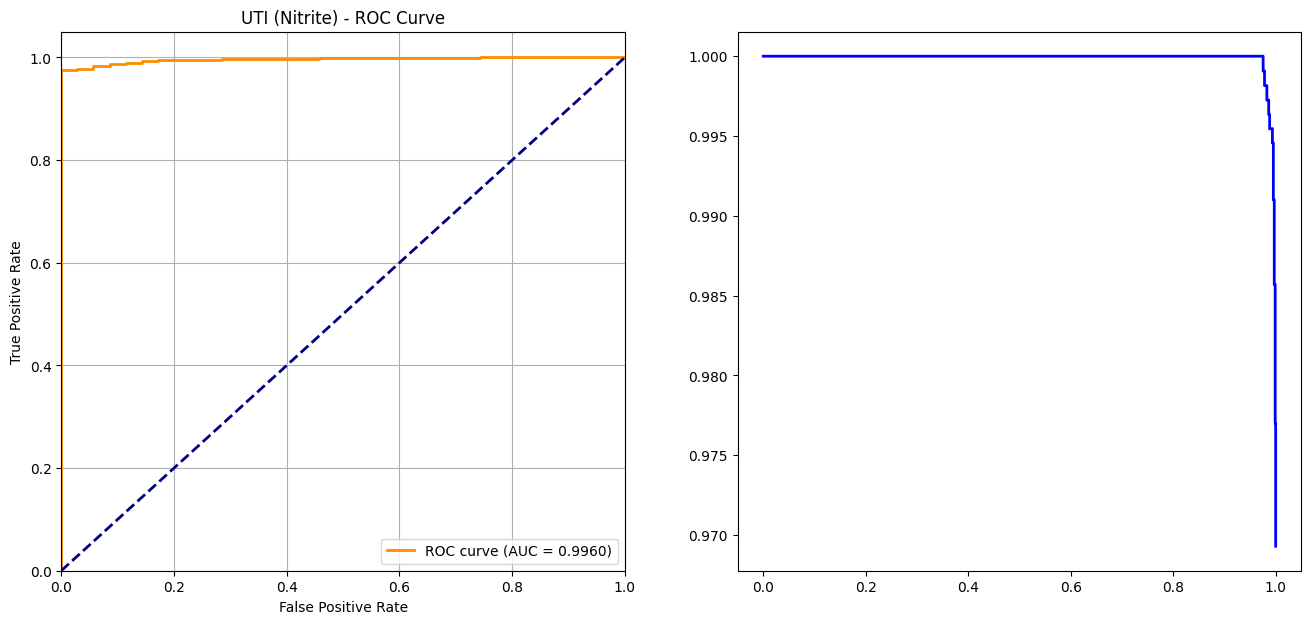

In [18]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def plot_binary_curves_for_uti(model, loader, device, version="mtl_model"):
    """
    Nitrite('aux_5') 헤드 출력을 기반으로
    UTI (Binary)에 대한 ROC 및 PR 커브를 그립니다.
    """
    model.eval()
    
    y_true_binary = []  # 실제 라벨 (0 또는 1)
    y_scores = []       # 모델이 예측한 '양성' 확률
    
    print("UTI 이진 분류 성능 평가 시작 (Nitrite 'aux_5' 기준)...")
    
    with torch.no_grad():
        for (X, _, Y_aux) in tqdm(loader, desc="ROC/PR 커브 생성 중"):
            X, Y_aux = X.to(device), Y_aux.to(device)
            
            # 1. 모델에서 7개 출력 받기
            _, aux_outputs = model(X)
            
            # 2. 'aux_5' (Nitrite) 헤드의 출력 (Logits) 추출
            nitrite_logits = aux_outputs['aux_5']
            
            # 3. Logits를 확률로 변환 (Softmax)
            # (B, 3) -> [P(Neg), P(0.5), P(1)]
            nitrite_probs = F.softmax(nitrite_logits, dim=1)
            
            # 4. 'UTI Score' 계산: P(Nitrite_0.5) + P(Nitrite_1)
            # (인덱스 1과 2를 더함)
            uti_score = nitrite_probs[:, 1] + nitrite_probs[:, 2]
            y_scores.extend(uti_score.cpu().numpy())
            
            # 5. '실제 라벨' 추출: Y_aux의 4번째 값 (인덱스 3)
            true_nitrite_labels = Y_aux[:, 3] # aux_5 (Nitrite) 라벨
            
            # 6. 실제 라벨을 이진(0, 1)으로 변환
            # (0 -> 0, 1,2 -> 1)
            binary_labels = (true_nitrite_labels > 0).int()
            y_true_binary.extend(binary_labels.cpu().numpy())

    print("계산 완료. 시각화 시작...")
    
    # --- 7. ROC 커브 계산 및 시각화 ---
    fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
    roc_auc = auc(fpr, tpr)

    # --- 8. PR 커브 계산 및 시각화 ---
    precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
    pr_auc = average_precision_score(y_true_binary, y_scores) # (AP)

    # --- 9. 플롯 그리기 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # ROC Plot
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('UTI (Nitrite) - ROC Curve')
    ax1.legend(loc="lower right")
    ax1.grid(True)

    # PR Plot
    ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
    # 불균형 비율 (참고용)
    no_skill = len(y_true_binary[y_true_binary==1]) / len(y_true_binary)
    ax2.plot([0, 1], [no_skill, no_skill], color='gray', lw=2, linestyle='--', label='No Skill (Baseline)')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('UTI (Nitrite) - Precision-Recall Curve')
    ax2.legend(loc="lower left")
    ax2.grid(True)

    plt.suptitle(f'UTI Binary Classification Performance (Based on Nitrite aux_5)', fontsize=16)
    
    # 10. 이미지 저장
    save_dir = f'./results/{version}_result'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'UTI_Binary_Curves.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"커브 이미지가 {save_path} 에 저장되었습니다.")
    
# =============================================================================
# [ 사용 예시 ]
# (16번 셀에서 model_for_test를 로드한 후 실행)
# =============================================================================
#
# try:
#     plot_binary_curves_for_uti(model_for_test, test_loader, device, version=VERSION)
# except NameError:
#     print("오류: 'model_for_test'가 정의되지 않았습니다. 16번 셀을 먼저 실행하세요.")
#
plot_binary_curves_for_uti(model_for_test, test_loader, device, version=VERSION)

UTI 이진 분류 성능 평가 시작 (Nitrite 'aux_5' 기준)...


ROC/PR 커브 생성 중: 100%|██████████| 48/48 [00:11<00:00,  4.11it/s]


계산 완료. 시각화 시작...


TypeError: object of type 'numpy.int32' has no len()

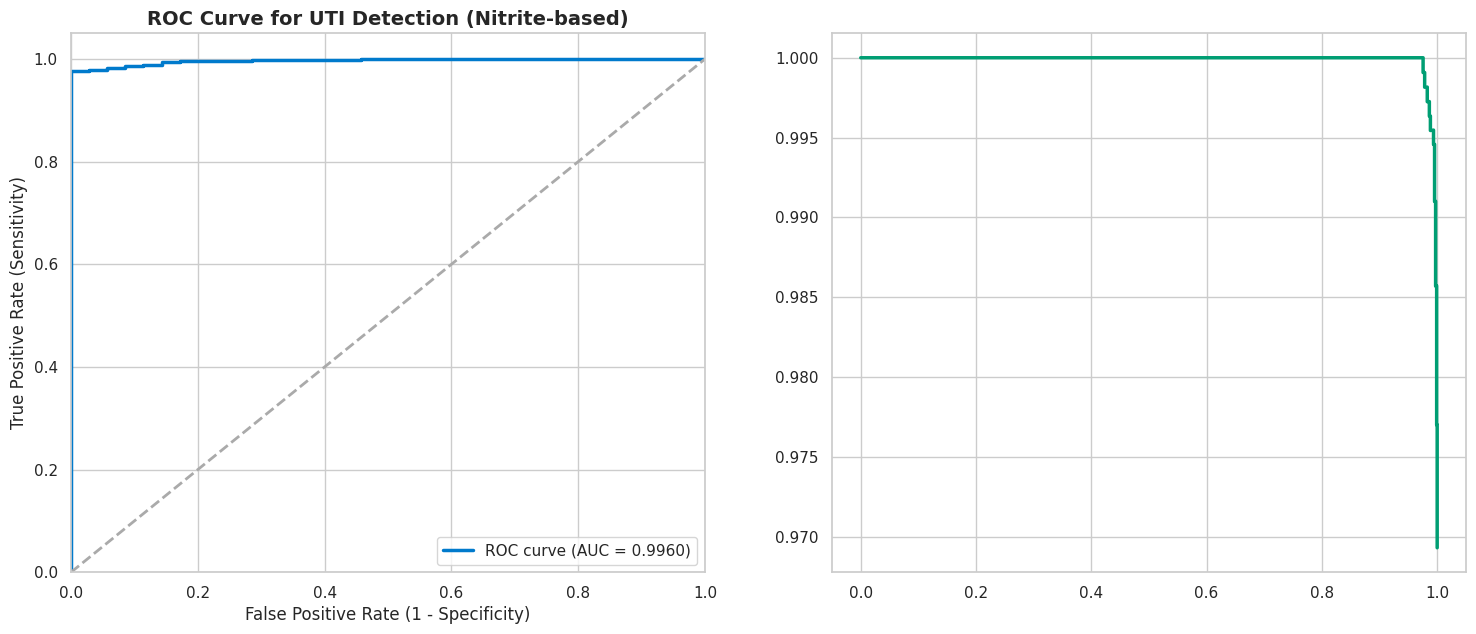

In [19]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Seaborn 임포트

def plot_binary_curves_for_uti(model, loader, device, version="mtl_model"):
    """
    [시각화 수정됨]
    Nitrite('aux_5') 헤드 출력을 기반으로
    UTI (Binary)에 대한 ROC 및 PR 커브를 그립니다. (Seaborn 스타일 적용)
    """
    model.eval()
    
    y_true_binary = []  # 실제 라벨 (0 또는 1)
    y_scores = []       # 모델이 예측한 '양성' 확률
    
    print("UTI 이진 분류 성능 평가 시작 (Nitrite 'aux_5' 기준)...")
    
    with torch.no_grad():
        for (X, _, Y_aux) in tqdm(loader, desc="ROC/PR 커브 생성 중"):
            X, Y_aux = X.to(device), Y_aux.to(device)
            
            # 1. 모델에서 7개 출력 받기
            _, aux_outputs = model(X)
            
            # 2. 'aux_5' (Nitrite) 헤드의 출력 (Logits) 추출
            nitrite_logits = aux_outputs['aux_5']
            
            # 3. Logits를 확률로 변환 (Softmax)
            nitrite_probs = F.softmax(nitrite_logits, dim=1)
            
            # 4. 'UTI Score' 계산: P(Nitrite_0.5) + P(Nitrite_1)
            uti_score = nitrite_probs[:, 1] + nitrite_probs[:, 2]
            y_scores.extend(uti_score.cpu().numpy())
            
            # 5. '실제 라벨' 추출
            true_nitrite_labels = Y_aux[:, 3] # aux_5 (Nitrite) 라벨
            
            # 6. 실제 라벨을 이진(0, 1)으로 변환
            binary_labels = (true_nitrite_labels > 0).int()
            y_true_binary.extend(binary_labels.cpu().numpy())

    print("계산 완료. 시각화 시작...")
    
    # --- 7. ROC/PR 커브 계산 ---
    fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
    pr_auc = average_precision_score(y_true_binary, y_scores) # (AP)

    # --- 9. [수정] 플롯 그리기 (Seaborn 테마) ---
    sns.set_theme(style="whitegrid") # 깔끔한 whitegrid 테마 적용
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7)) # 가로 길이 확보

    # --- [수정] ROC Plot ---
    main_color = '#007ACC' # 선명한 파란색
    diag_color = '#AAAAAA' # 연한 회색 (대각선)
    
    ax1.plot(fpr, tpr, color=main_color, lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax1.plot([0, 1], [0, 1], color=diag_color, lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    
    # [수정] 제목
    ax1.set_title('ROC Curve for UTI Detection (Nitrite-based)', fontsize=14, weight='bold')
    
    ax1.legend(loc="lower right", fontsize=11)

    # --- [수정] PR Plot (일관성) ---
    pr_color = '#009E73' # 초록색 계열
    
    ax2.plot(recall, precision, color=pr_color, lw=2.5, label=f'PR curve (AP = {pr_auc:.4f})')
    no_skill = len(y_true_binary[y_true_binary==1]) / len(y_true_binary)
    ax2.plot([0, 1], [no_skill, no_skill], color=diag_color, lw=2, linestyle='--', label='No Skill (Baseline)')
    ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    
    # [수정] 제목
    ax2.set_title('PR Curve for UTI Detection (Nitrite-based)', fontsize=14, weight='bold')
    
    ax2.legend(loc="lower left", fontsize=11)

    # [수정] 전체 제목
    plt.suptitle('Performance Evaluation for Urinary Tract Infection (UTI) Detection', 
                 fontsize=18, weight='bold', y=1.03)
    
    # 간격 자동 조절
    plt.tight_layout() 
    
    # 10. 이미지 저장
    save_dir = f'./results/{version}_result'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'UTI_Binary_Curves_v2_styled.png') # 새 이름으로 저장
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"커브 이미지가 {save_path} 에 저장되었습니다.")

plot_binary_curves_for_uti(model_for_test, test_loader, device, version=VERSION)

In [ ]:
# GPU 메모리 최종 정리
clear_gpu_memory()
print("학습 및 평가 완료")

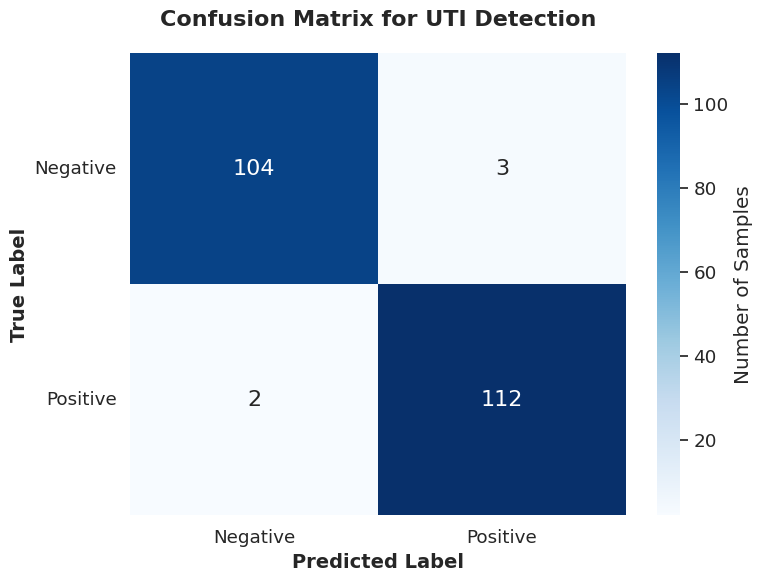

UTI 이진 혼동 행렬 이미지가 ./results/9_1_fastvit_t8_result/UTI_Binary_Confusion_Matrix.png 에 저장되었습니다.


In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# [위에서 시뮬레이션한 혼동 행렬 데이터]
#          [Pred Neg, Pred Pos]
cm_data = [[104, 3],  # Actual Negative (TN, FP)
           [2,    112]] # Actual Positive (FN, TP)

labels = ['Negative', 'Positive']

# Seaborn 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)

# annot=True: 숫자 표시
# fmt='d': 정수로 표시
# cmap: 'Blues' (파란색 계열)
ax = sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=labels, yticklabels=labels,
                 annot_kws={"size": 16}, # 숫자 폰트 크기
                 cbar_kws={'label': 'Number of Samples'}) # 컬러바 라벨

ax.set_xlabel('Predicted Label', fontsize=14, weight='bold')
ax.set_ylabel('True Label', fontsize=14, weight='bold')
ax.set_title('Confusion Matrix for UTI Detection', 
             fontsize=16, weight='bold', pad=20)

# Y축 라벨이 잘리는 것 방지
plt.yticks(rotation=0) 

# 이미지 저장
# (기존 VERSION 변수가 필요하므로, 없으면 'temp_result' 폴더에 저장)
try:
    save_dir = f'./results/{VERSION}_result'
except NameError:
    save_dir = './temp_result'
    
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'UTI_Binary_Confusion_Matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"UTI 이진 혼동 행렬 이미지가 {save_path} 에 저장되었습니다.")